# XGBoost backcasting notebook: global model + NNH-specific models

This notebook trains

- a global XGBoost model on all the data,
- three separate models for nnh_region = 1, 2, 3,
- and generates comparison plots for performance, training progress, and feature importance.

1) Load data
2) Select features (ibap_B*_med + nbr_sen_slope)
3) Generate tile-based train/val/test split
4) Train evaluation model with early stopping
5) Optimize threshold on the validation set
6) Calculate test metrics
7) Train final production classifier on all rows of the respective subset
8) Generate comparison plots


In [33]:
import sys
import subprocess
import importlib
from pathlib import Path
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
}

missing = []

for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f"{import_name} already installed")
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed")

Installing missing packages: ['seaborn', 'pyarrow']
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 113.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [seaborn]m1/2 [seaborn]


In [34]:
import sys
import subprocess
import importlib
from pathlib import Path
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
}

missing = []

for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f"{import_name} already installed")
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed")

numpy already installed
pandas already installed
matplotlib already installed
sklearn already installed
xgboost already installed
All required packages are already installed


In [35]:
# ----------------------------
# SETTINGS
# ----------------------------

IN_FILE = "/mnt/eo/EO4Backcasting/model_input/2303/training_selected_ibap_nbr_NNH.csv"
OUT_ROOT = "/mnt/eo/EO4Backcasting/_training_output/2303"

Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1) < 1e-8

XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_estimators=1000,
    random_state=RANDOM_STATE,
    n_jobs=max(1, (os.cpu_count() or 2) - 1),
)

EARLY_STOPPING_ROUNDS = 40
THRESHOLD_GRID = np.round(np.arange(0.10, 0.901, 0.01), 2)

In [3]:
# ----------------------------
# HELPERS
# ----------------------------

def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ok = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[ok]
    y_prob = y_prob[ok]
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))


def calc_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ok = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[ok]
    y_prob = y_prob[ok]

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auc": safe_auc(y_true, y_prob),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def find_best_f1_threshold(y_true, y_prob, thresholds=THRESHOLD_GRID):
    rows = [calc_metrics(y_true, y_prob, thr) for thr in thresholds]
    out = pd.DataFrame(rows)
    out = out.sort_values(["f1", "threshold"], ascending=[False, True]).reset_index(drop=True)
    return out.iloc[0], out


def feature_label(feature):
    if feature == "nbr_sen_slope":
        return "NBR slope"
    if feature.startswith("ibap_B") and feature.endswith("_med"):
        band_num = feature.replace("ibap_B", "").replace("_med", "")
        return f"Band {band_num}"
    return feature


def model_label(model_name):
    mapping = {
        "global": "Global",
        "nnh_region_1": "Boreal",
        "nnh_region_2": "Temperate",
        "nnh_region_3": "Mediterranean",
    }
    return mapping.get(model_name, model_name)


def ensure_binary_labels(y, model_name, split_name):
    u = sorted(pd.Series(y).dropna().unique().tolist())
    if not set(u).issubset({0, 1}):
        raise ValueError(f"{model_name} / {split_name}: labels are not binary 0/1: {u}")
    if len(u) < 2:
        print(f"Warning: {model_name} / {split_name} contains only one class. AUC will be NaN.")


def make_tile_split(df, tile_col="tile", train_frac=0.7, val_frac=0.15, random_state=42):
    tiles = pd.Series(df[tile_col].dropna().unique()).sample(frac=1, random_state=random_state).tolist()

    n_tiles = len(tiles)
    n_train = int(np.floor(n_tiles * train_frac))
    n_val = int(np.floor(n_tiles * val_frac))
    n_test = n_tiles - n_train - n_val

    if min(n_train, n_val, n_test) < 1:
        raise ValueError("Too few tiles for requested train/val/test split.")

    train_tiles = set(tiles[:n_train])
    val_tiles = set(tiles[n_train:n_train + n_val])
    test_tiles = set(tiles[n_train + n_val:])

    split = np.where(
        df[tile_col].isin(train_tiles), "train",
        np.where(df[tile_col].isin(val_tiles), "val", "test")
    )

    out = df.copy()
    out["split"] = split
    return out, sorted(train_tiles), sorted(val_tiles), sorted(test_tiles)

In [20]:
# ----------------------------
# LOAD DATA
# ----------------------------

df = pd.read_csv(IN_FILE)

required_cols = [
    "point_id",
    "tile",
    "label_undisturbed_20y",
    "NNH",
    "nbr_mean",
    "nbr_sd",
    "nbr_range",
    "nbr_sen_slope",
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

ibap_cols = [c for c in df.columns if c.startswith("ibap_B") and c.endswith("_med")]
ibap_cols = sorted(
    ibap_cols,
    key=lambda x: int(x.replace("ibap_B", "").replace("_med", ""))
)

if len(ibap_cols) == 0:
    raise ValueError("No IBAP feature columns found.")

expected_ibap = [f"ibap_B{i}_med" for i in range(1, 7)]
missing_ibap = [c for c in expected_ibap if c not in ibap_cols]
if missing_ibap:
    raise ValueError(f"Missing IBAP columns: {missing_ibap}")

nbr_cols = [
    "nbr_mean",
    "nbr_sd",
    "nbr_range",
    "nbr_sen_slope",
]

FEATURE_COLS = expected_ibap + nbr_cols

for c in FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["label_undisturbed_20y"] = pd.to_numeric(
    df["label_undisturbed_20y"], errors="coerce"
).astype("Int64")

df["NNH"] = pd.to_numeric(df["NNH"], errors="coerce").astype("Int64")

n_before = len(df)

df = df[df["label_undisturbed_20y"].isin([0, 1])].copy()
df = df[df["NNH"].isin([1, 2, 3])].copy()

df = df.dropna(
    subset=FEATURE_COLS + ["point_id", "tile", "label_undisturbed_20y", "NNH"]
).copy()

df["label_undisturbed_20y"] = df["label_undisturbed_20y"].astype(int)
df["NNH"] = df["NNH"].astype(int)

# Rename / label NNH classes
nnh_map = {
    1: "Boreal",
    2: "Temperate",
    3: "Mediterranean",
}
df["NNH_name"] = df["NNH"].map(nnh_map)

# Optional: ordered categorical for cleaner plots/tables
df["NNH_name"] = pd.Categorical(
    df["NNH_name"],
    categories=["Boreal", "Temperate", "Mediterranean"],
    ordered=True
)

print(f"Removed rows: {n_before - len(df):,}")
print(f"Rows kept: {len(df):,}")
print(f"Tiles kept: {df['tile'].nunique():,}")

print("Feature columns used:")
print(FEATURE_COLS)

print("Class balance:")
display(
    df["label_undisturbed_20y"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

print("NNH balance (numeric):")
display(
    df["NNH"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

print("NNH balance (named):")
display(
    df["NNH_name"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

Removed rows: 0
Rows kept: 390,987
Tiles kept: 395
Feature columns used:
['ibap_B1_med', 'ibap_B2_med', 'ibap_B3_med', 'ibap_B4_med', 'ibap_B5_med', 'ibap_B6_med', 'nbr_mean', 'nbr_sd', 'nbr_range', 'nbr_sen_slope']
Class balance:


,n_rows
label_undisturbed_20y,
0,195091
1,195896


NNH balance (numeric):


,n_rows
NNH,
1,66374
2,233714
3,90899


NNH balance (named):


,n_rows
NNH_name,
Boreal,66374
Temperate,233714
Mediterranean,90899


## Model functions

The next cell runs the complete workflow for a subset:

- Tile-based split
- Evaluation model with early stopping
- Metrics for 0.5 and the optimal validation threshold
- Export of CSV files, PNGs, and the final model
- Return of all results for later comparison

In [21]:
def run_xgb_workflow(
    df_sub,
    model_name,
    feature_cols,
    out_root,
    params,
    early_stopping_rounds=40,
    train_frac=0.70,
    val_frac=0.15,
    random_state=42,
):
    out_dir = Path(out_root) / model_name
    plot_dir = out_dir / "plots"
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print(f"Running model: {model_name}")
    print(f"Rows:  {len(df_sub):,}")
    print(f"Tiles: {df_sub['tile'].nunique():,}")
    print(df_sub["label_undisturbed_20y"].value_counts().sort_index())

    df_split, train_tiles, val_tiles, test_tiles = make_tile_split(
        df_sub,
        tile_col="tile",
        train_frac=train_frac,
        val_frac=val_frac,
        random_state=random_state,
    )

    train_df = df_split[df_split["split"] == "train"].copy()
    val_df = df_split[df_split["split"] == "val"].copy()
    test_df = df_split[df_split["split"] == "test"].copy()

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(f"{model_name}: one split is empty.")

    ensure_binary_labels(train_df["label_undisturbed_20y"], model_name, "train")
    ensure_binary_labels(val_df["label_undisturbed_20y"], model_name, "val")
    ensure_binary_labels(test_df["label_undisturbed_20y"], model_name, "test")

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df["label_undisturbed_20y"].to_numpy(dtype=int)

    X_val = val_df[feature_cols].to_numpy(dtype=float)
    y_val = val_df["label_undisturbed_20y"].to_numpy(dtype=int)

    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df["label_undisturbed_20y"].to_numpy(dtype=int)

    # ----------------------------
    # evaluation model
    # ----------------------------
    model_eval = xgb.XGBClassifier(**params)
    model_eval.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

    evals_result = model_eval.evals_result()
    train_logloss = evals_result["validation_0"]["logloss"]
    val_logloss = evals_result["validation_1"]["logloss"]

    best_iter = getattr(model_eval, "best_iteration", None)
    if best_iter is None:
        best_iter = int(np.argmin(val_logloss))

    pred_train = model_eval.predict_proba(X_train)[:, 1]
    pred_val = model_eval.predict_proba(X_val)[:, 1]
    pred_test = model_eval.predict_proba(X_test)[:, 1]

    # ----------------------------
    # best threshold from validation set using F1 optimization
    # ----------------------------
    best_thr_row, thr_grid = find_best_f1_threshold(y_val, pred_val)
    best_thr = float(best_thr_row["threshold"])

    metrics_rows = []
    for split_name, y_true, y_prob in [
        ("train", y_train, pred_train),
        ("val", y_val, pred_val),
        ("test", y_test, pred_test),
    ]:
        m_fixed = calc_metrics(y_true, y_prob, threshold=0.5)
        m_fixed["split"] = split_name
        m_fixed["threshold_type"] = "fixed_0.5"
        m_fixed["model"] = model_name

        m_opt = calc_metrics(y_true, y_prob, threshold=best_thr)
        m_opt["split"] = split_name
        m_opt["threshold_type"] = "best_val_f1"
        m_opt["model"] = model_name

        metrics_rows.extend([m_fixed, m_opt])

    metrics_all = pd.DataFrame(metrics_rows)

    auc_summary = pd.DataFrame({
        "model": [model_name, model_name, model_name],
        "split": ["train", "val", "test"],
        "auc": [
            safe_auc(y_train, pred_train),
            safe_auc(y_val, pred_val),
            safe_auc(y_test, pred_test),
        ]
    })

    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Gain": model_eval.feature_importances_,
    }).sort_values("Gain", ascending=False).reset_index(drop=True)
    importance["model"] = model_name
    importance["Feature_clean"] = importance["Feature"].map(feature_label)
    importance["rank_gain"] = np.arange(1, len(importance) + 1)

    pred_out = pd.DataFrame({
        "model": model_name,
        "point_id": test_df["point_id"].values,
        "tile": test_df["tile"].values,
        "y_true": y_test,
        "p_undisturbed": pred_test,
        "pred_class_05": (pred_test >= 0.5).astype(int),
        "pred_class_opt": (pred_test >= best_thr).astype(int),
    })

    eval_log = pd.DataFrame({
        "iter": np.arange(1, len(train_logloss) + 1),
        "train_logloss": train_logloss,
        "val_logloss": val_logloss,
        "model": model_name,
    })

    # save tabular outputs
    pd.DataFrame({"feature": feature_cols}).to_csv(out_dir / "feature_list.csv", index=False)
    pd.DataFrame({"tile": train_tiles, "split": "train"}).to_csv(out_dir / "tiles_train.csv", index=False)
    pd.DataFrame({"tile": val_tiles, "split": "val"}).to_csv(out_dir / "tiles_val.csv", index=False)
    pd.DataFrame({"tile": test_tiles, "split": "test"}).to_csv(out_dir / "tiles_test.csv", index=False)

    pd.DataFrame([best_thr_row]).to_csv(out_dir / "best_threshold_from_val.csv", index=False)
    metrics_all.to_csv(out_dir / "metrics_all_splits.csv", index=False)
    auc_summary.to_csv(out_dir / "auc_summary.csv", index=False)
    importance.to_csv(out_dir / "feature_importance.csv", index=False)
    pred_out.to_csv(out_dir / "test_predictions.csv", index=False)
    eval_log.to_csv(out_dir / "evaluation_log.csv", index=False)
    thr_grid.to_csv(out_dir / "validation_threshold_grid.csv", index=False)

    model_eval.save_model(out_dir / "xgb_model_eval.json")

    # ----------------------------
    # final model trained on all rows of subset
    # use best iteration from eval model
    # ----------------------------
    X_all = df_sub[feature_cols].to_numpy(dtype=float)
    y_all = df_sub["label_undisturbed_20y"].to_numpy(dtype=int)

    final_params = dict(params)
    final_params["n_estimators"] = best_iter + 1

    model_final = xgb.XGBClassifier(**final_params)
    model_final.fit(X_all, y_all, verbose=False)
    model_final.save_model(out_dir / "xgb_model_final.json")

    # ----------------------------
    # PLOTS
    # ----------------------------

    # 1) Training history: logloss
    fig, ax = plt.subplots()
    ax.plot(eval_log["iter"], eval_log["train_logloss"], label="train")
    ax.plot(eval_log["iter"], eval_log["val_logloss"], label="validation")
    ax.axvline(best_iter + 1, linestyle="--", label="best iteration")
    ax.set_title(f"Training history: logloss ({model_label(model_name)})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Logloss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "training_history_logloss.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 2) AUC by split
    fig, ax = plt.subplots()
    ax.bar(auc_summary["split"], auc_summary["auc"])
    ax.set_title(f"AUC by split ({model_label(model_name)})")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("AUC")
    fig.tight_layout()
    fig.savefig(plot_dir / "auc_by_split.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 3) Feature importance
    feature_order = (
        [f"Band {i}" for i in range(1, 7)]
        + ["NBR mean", "NBR min", "NBR max", "NBR sd", "NBR MAD", "NBR range", "NBR slope"]
    )

    imp_plot = importance.copy()
    imp_plot = imp_plot[imp_plot["Feature_clean"].isin(feature_order)].copy()
    imp_plot["Feature_clean"] = pd.Categorical(
        imp_plot["Feature_clean"],
        categories=feature_order[::-1],
        ordered=True,
    )
    imp_plot = imp_plot.sort_values("Feature_clean")

    fig, ax = plt.subplots()
    ax.barh(imp_plot["Feature_clean"], imp_plot["Gain"])
    ax.set_title(f"Feature importance ({model_label(model_name)})")
    ax.set_xlabel("Gain")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(plot_dir / "feature_importance_ordered.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 4) Test prediction histogram
    fig, ax = plt.subplots()
    ax.hist(pred_test[y_test == 0], bins=40, alpha=0.5, label="disturbed")
    ax.hist(pred_test[y_test == 1], bins=40, alpha=0.5, label="undisturbed")
    ax.set_title(f"Predicted probabilities on test tiles ({model_label(model_name)})")
    ax.set_xlabel("Predicted probability of undisturbed")
    ax.set_ylabel("Count")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "test_prediction_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 5) Validation threshold metrics
    fig, ax = plt.subplots()
    ax.plot(thr_grid["threshold"], thr_grid["precision"], label="precision")
    ax.plot(thr_grid["threshold"], thr_grid["recall"], label="recall")
    ax.plot(thr_grid["threshold"], thr_grid["f1"], label="f1")
    ax.axvline(best_thr, linestyle="--", label=f"best F1 threshold = {best_thr:.2f}")
    ax.set_title(f"Validation metrics across thresholds ({model_label(model_name)})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "validation_threshold_metrics.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Best iteration: {best_iter + 1}")
    print(f"Best validation threshold (F1): {best_thr:.2f}")

    return {
        "model_name": model_name,
        "metrics_all": metrics_all,
        "auc_summary": auc_summary,
        "importance": importance,
        "evaluation_log": eval_log,
        "predictions": pred_out,
        "best_threshold": best_thr_row.to_dict(),
        "best_iteration": best_iter + 1,
        "model_eval": model_eval,
        "model_final": model_final,
    }

In [23]:
def feature_label(feature):
    if feature == "nbr_mean":
        return "NBR mean"
    if feature == "nbr_sd":
        return "NBR sd"
    if feature == "nbr_range":
        return "NBR range"
    if feature == "nbr_sen_slope":
        return "NBR slope"
    if feature.startswith("ibap_B") and feature.endswith("_med"):
        band_num = feature.replace("ibap_B", "").replace("_med", "")
        return f"Band {band_num}"
    return feature

## Execute global and biome-specific models

Running model: global
Rows:  390,987
Tiles: 395
label_undisturbed_20y
0    195091
1    195896
Name: count, dtype: int64


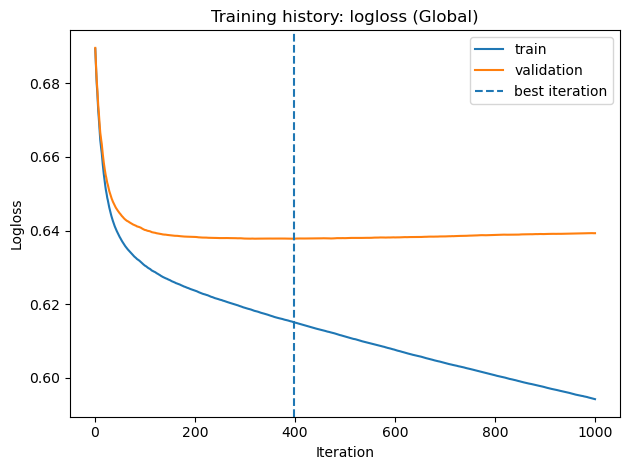

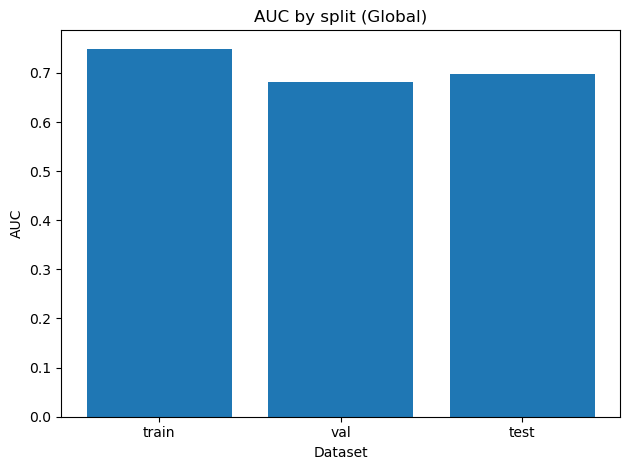

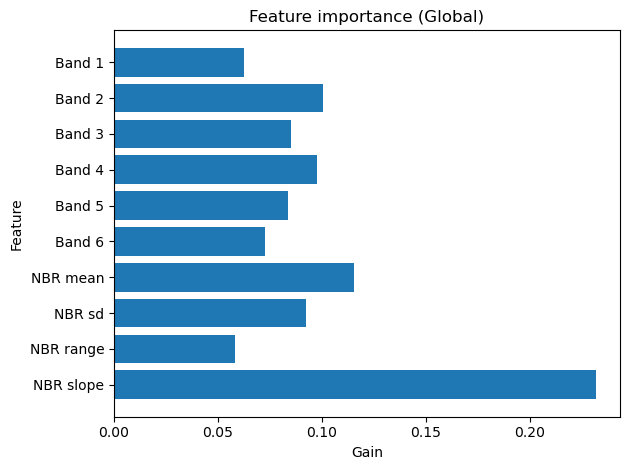

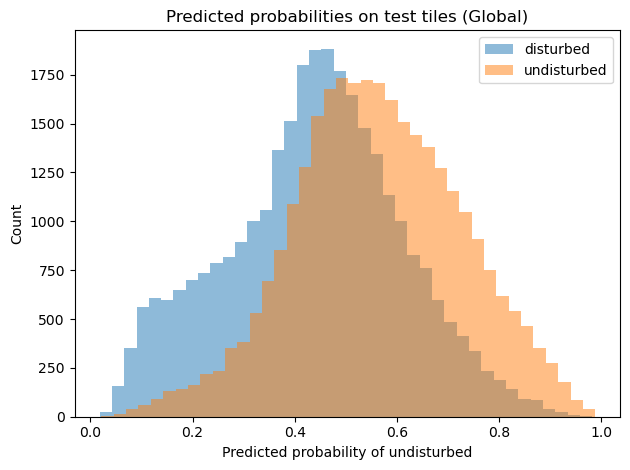

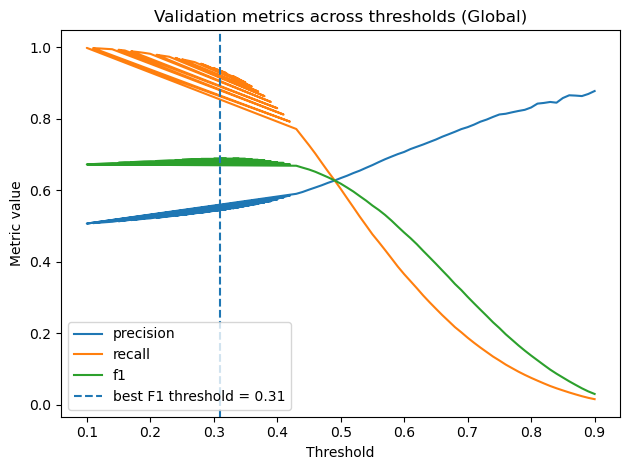

Best iteration: 398
Best validation threshold (F1): 0.31
Running model: nnh_region_1
Rows:  66,374
Tiles: 72
label_undisturbed_20y
0    33015
1    33359
Name: count, dtype: int64


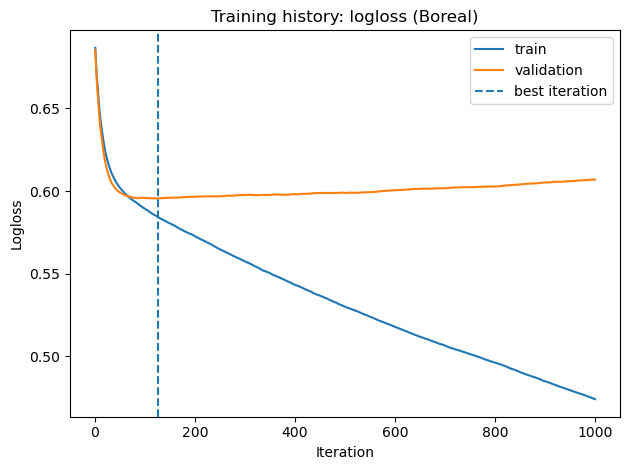

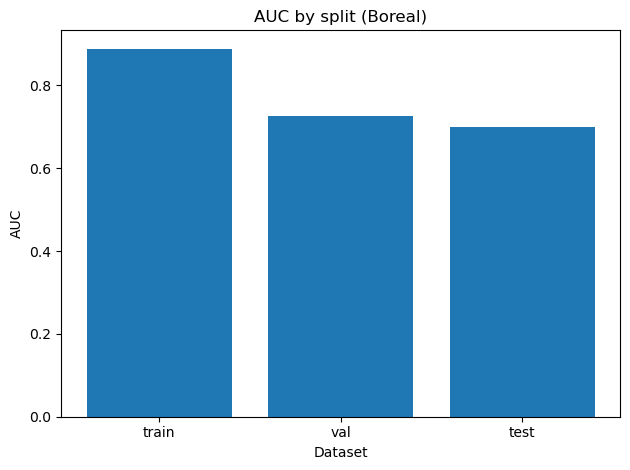

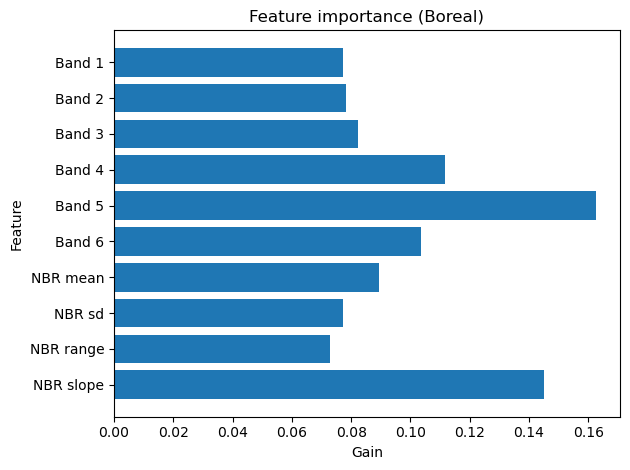

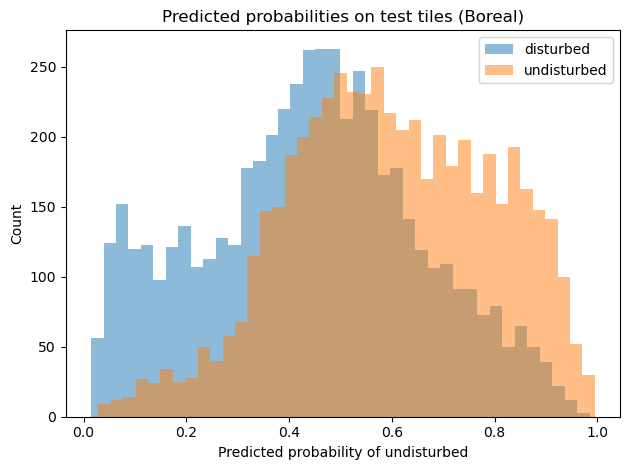

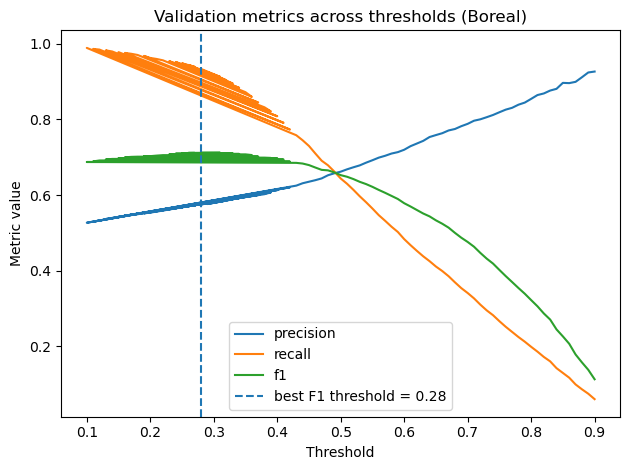

Best iteration: 126
Best validation threshold (F1): 0.28
Running model: nnh_region_2
Rows:  233,714
Tiles: 258
label_undisturbed_20y
0    116406
1    117308
Name: count, dtype: int64


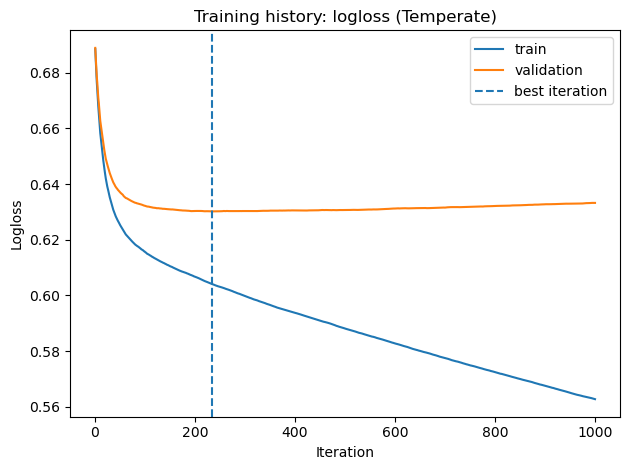

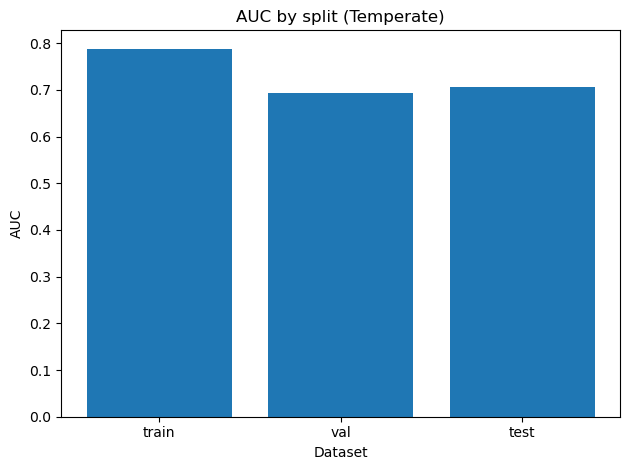

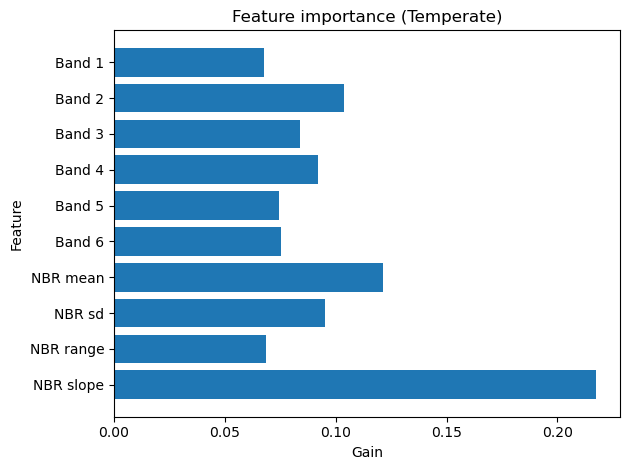

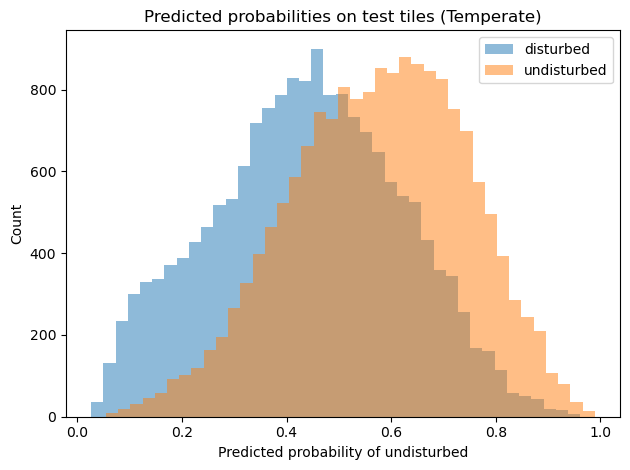

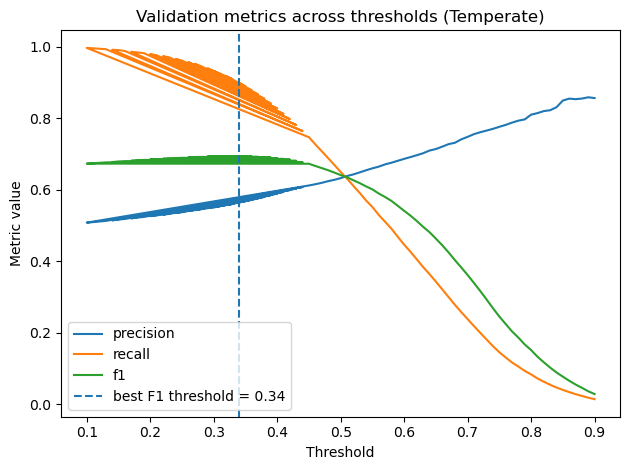

Best iteration: 235
Best validation threshold (F1): 0.34
Running model: nnh_region_3
Rows:  90,899
Tiles: 111
label_undisturbed_20y
0    45670
1    45229
Name: count, dtype: int64


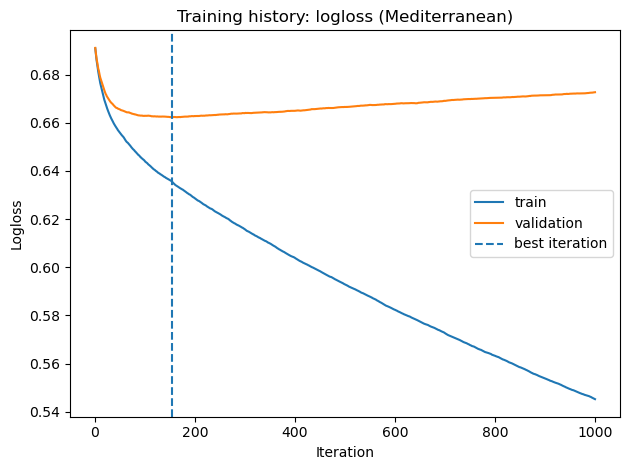

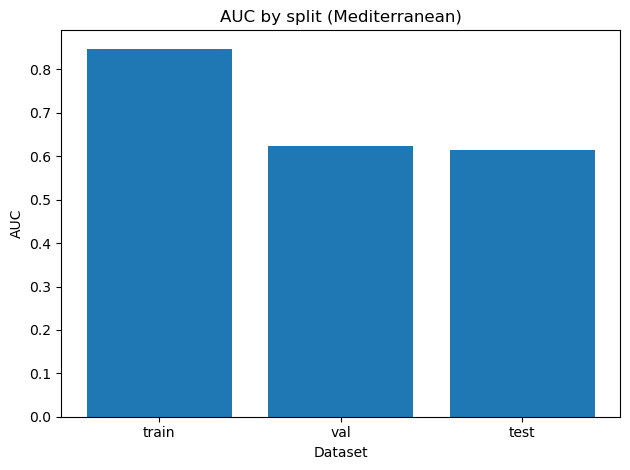

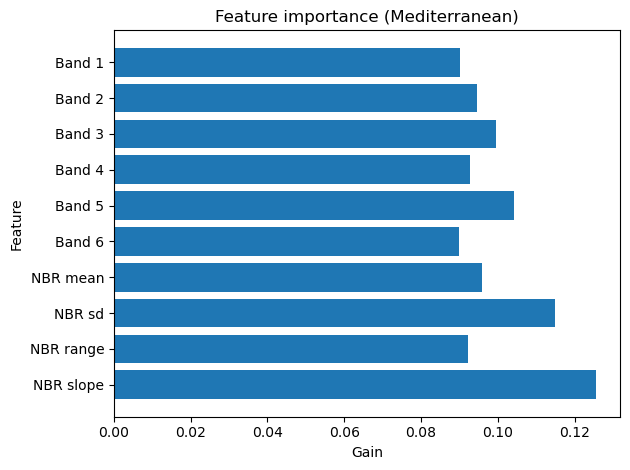

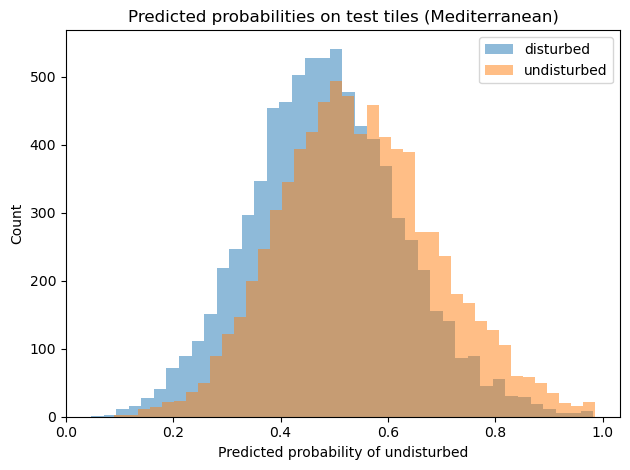

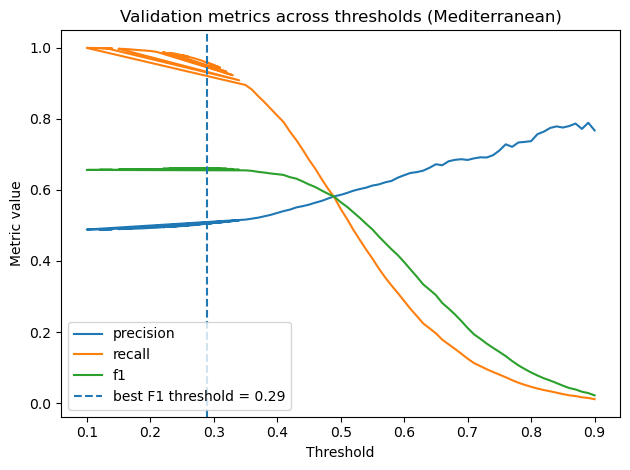

Best iteration: 154
Best validation threshold (F1): 0.29


In [24]:
model_specs = {
    "global": df.copy(),
    "nnh_region_1": df[df["NNH"] == 1].copy(),
    "nnh_region_2": df[df["NNH"] == 2].copy(),
    "nnh_region_3": df[df["NNH"] == 3].copy(),
}

results = {}

for model_name, df_sub in model_specs.items():
    if len(df_sub) == 0:
        print(f"Skipping {model_name}: empty subset")
        continue

    results[model_name] = run_xgb_workflow(
        df_sub=df_sub,
        model_name=model_name,
        feature_cols=FEATURE_COLS,
        out_root=OUT_ROOT,
        params=XGB_PARAMS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        random_state=RANDOM_STATE,
    )

**Global**
  
Fig.1 : Logloss (global): Trainings-Logloss sinkt kontinuierlich, Valdierungs-Logloss flacht früh ab und steigt ganz leicht -> beginnendes overfitting.
Nach Iteration ~450 wird nur noch Trainngsfehler besser, nicht aber Generalisierung

Fig.2: AUC by split: Val und Test nah beinander, gut. Klassen werden nicht besonders gut getrennt.

Fig. 3: Feature importance: NBR slope wichtigster Prädiktor.

Fig.4: Predicted probablities on test tile: Verteilungen überlappen sehr stark. Passt zu nur mittel gutem Test AUC.

Fig.5: Validation metrics across thresholds: Beste F1 score bei ~0.34. Niedrig und zeigt, dass Modell für die undisturbed Klasse eher konservativ trennt. Bei höheren Schwellwerten steigt zwar Precision, aber recall bricht ein.

**Boreal**
Fig.6: Logloss boreal: Overfitting setzte früher ein. Early stopping macht hier Sinn

Fig- 8: Feature importance borel: Interessant: Band 5 am wichtigsten (SWIR), gefolgt von NBR slope

Fig. 9: Verteilung boreal: Histogramme etwas besser getrennt als im globalen Modell

**Temperate**
    
Fig. 10: Logloss temperate: Overfitting setzt erst später ein

Fig. 12: Feature importantce: NBR slope dominiert wieder

Fig. 13: Predicted probs: Klassen verschoben, aber immer noch überlappend

**Mediterran**

Fig. 14: Logloss: Deutliches overfitting, lernt Trainingsset gut aber generalisiert schlechter

Fig. 15: AUC: am schlechtesten

Fig. 16: Feature importance: Importance viel gleichmäßiger verteilt

Fig. 17: Histogramme überlappen sehr stark. Deshalb schwache Trennung

**Vergleichsplots**

- Regionale Modelle helfen nur teilweise, mediterran bleibt weiterhin schwierig

- Feature importance: NBR slope ist regionsabhängig und dort am wenigsten stabil, wo Modellgüte am schlechtesten

- ROC curves: Keines der Modelle trennt besonders gut


In [32]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from pathlib import Path

# # Boreal subset
# df_boreal = df[df["NNH"] == 1].copy()

# # Features und Labels
# X_boreal = df_boreal[FEATURE_COLS].copy()
# y_boreal = df_boreal["label_undisturbed_20y"].astype(int).copy()

# # Modell aus deinen Ergebnissen
# boreal_model = results["nnh_region_1"]["model_eval"]

# print("Boreal rows:", len(df_boreal))
# print("Features used:", FEATURE_COLS)
# print("Class balance:")
# print(y_boreal.value_counts().sort_index())

In [31]:
# fig, ax = plt.subplots(figsize=(7, 5))

# ax.hist(
#     df_boreal.loc[df_boreal["label_undisturbed_20y"] == 0, "ibap_B5_med"],
#     bins=40,
#     alpha=0.5,
#     label="disturbed"
# )

# ax.hist(
#     df_boreal.loc[df_boreal["label_undisturbed_20y"] == 1, "ibap_B5_med"],
#     bins=40,
#     alpha=0.5,
#     label="undisturbed"
# )

# ax.set_title("Boreal: distribution of ibap_B5_med by class")
# ax.set_xlabel("ibap_B5_med")
# ax.set_ylabel("Count")
# ax.legend()
# plt.tight_layout()
# plt.show()

In [13]:
metrics_compare = pd.concat([r["metrics_all"] for r in results.values()], ignore_index=True)
auc_compare = pd.concat([r["auc_summary"] for r in results.values()], ignore_index=True)
importance_compare = pd.concat([r["importance"] for r in results.values()], ignore_index=True)
eval_log_compare = pd.concat([r["evaluation_log"] for r in results.values()], ignore_index=True)

metrics_compare["model_clean"] = metrics_compare["model"].map(model_label)
auc_compare["model_clean"] = auc_compare["model"].map(model_label)
importance_compare["model_clean"] = importance_compare["model"].map(model_label)
eval_log_compare["model_clean"] = eval_log_compare["model"].map(model_label)

metrics_compare.to_csv(Path(OUT_ROOT) / "comparison_metrics_all_models.csv", index=False)
auc_compare.to_csv(Path(OUT_ROOT) / "comparison_auc_all_models.csv", index=False)
importance_compare.to_csv(Path(OUT_ROOT) / "comparison_feature_importance_all_models.csv", index=False)
eval_log_compare.to_csv(Path(OUT_ROOT) / "comparison_evaluation_logs_all_models.csv", index=False)

display(metrics_compare.head())
display(auc_compare)

,threshold,accuracy,precision,recall,specificity,f1,auc,tp,tn,fp,fn,split,threshold_type,model,model_clean
0,0.50,0.683425,0.684385,0.683206,0.683644,0.683795,0.754575,93565,93245,43149,43385,train,fixed_0.5,global,Global
1,0.33,0.605757,0.563440,0.946382,0.263743,0.706348,0.754575,129607,35973,100421,7343,train,best_val_f1,global,Global
2,0.50,0.626945,0.636121,0.600739,0.653378,0.617924,0.681701,17389,18750,9947,11557,val,fixed_0.5,global,Global
3,0.33,0.583072,0.550770,0.920645,0.242569,0.689219,0.681701,26649,6961,21736,2297,val,best_val_f1,global,Global
4,0.50,0.638933,0.639706,0.636167,0.641700,0.637932,0.697451,19085,19251,10749,10915,test,fixed_0.5,global,Global


,model,split,auc,model_clean
0,global,train,0.754575,Global
1,global,val,0.681701,Global
2,global,test,0.697451,Global
3,nnh_region_1,train,0.900066,Boreal
4,nnh_region_1,val,0.726328,Boreal
5,nnh_region_1,test,0.698293,Boreal
6,nnh_region_2,train,0.795167,Temperate
7,nnh_region_2,val,0.693554,Temperate
8,nnh_region_2,test,0.705592,Temperate
9,nnh_region_3,train,0.860601,Mediterranean


## Comparison plots

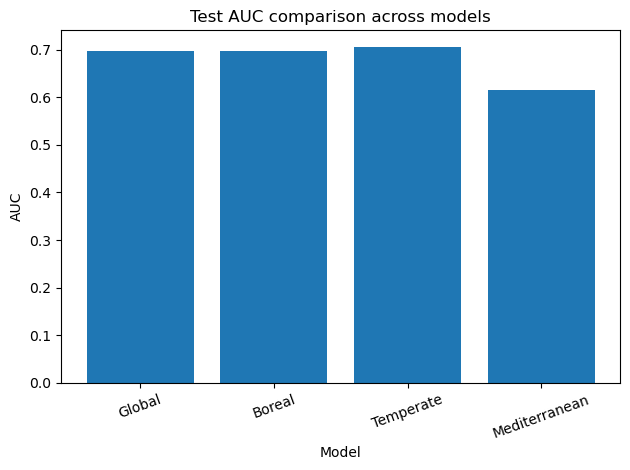

In [14]:
# 1) Test AUC comparison
auc_test = auc_compare[auc_compare["split"] == "test"].copy()
model_order = ["Global", "Boreal", "Temperate", "Mediterranean"]
auc_test["model_clean"] = pd.Categorical(auc_test["model_clean"], categories=model_order, ordered=True)
auc_test = auc_test.sort_values("model_clean")

fig, ax = plt.subplots()
ax.bar(auc_test["model_clean"], auc_test["auc"])
ax.set_title("Test AUC comparison across models")
ax.set_xlabel("Model")
ax.set_ylabel("AUC")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_auc.png", dpi=300, bbox_inches="tight")
plt.show()

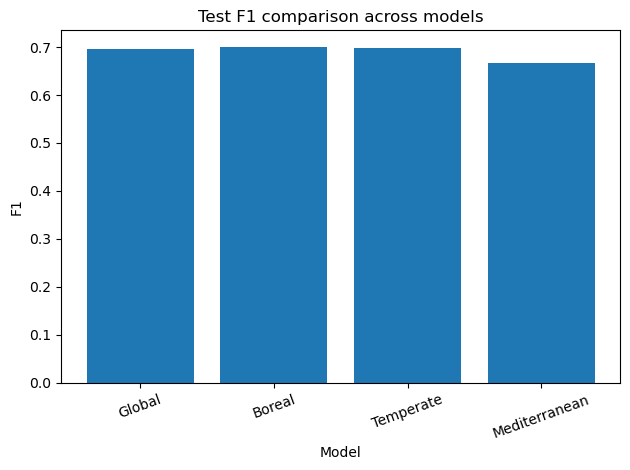

In [15]:
# 2) Test F1 comparison using best validation threshold
f1_test = metrics_compare[
    (metrics_compare["split"] == "test") &
    (metrics_compare["threshold_type"] == "best_val_f1")
].copy()

f1_test["model_clean"] = pd.Categorical(f1_test["model_clean"], categories=model_order, ordered=True)
f1_test = f1_test.sort_values("model_clean")

fig, ax = plt.subplots()
ax.bar(f1_test["model_clean"], f1_test["f1"])
ax.set_title("Test F1 comparison across models")
ax.set_xlabel("Model")
ax.set_ylabel("F1")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_f1.png", dpi=300, bbox_inches="tight")
plt.show()

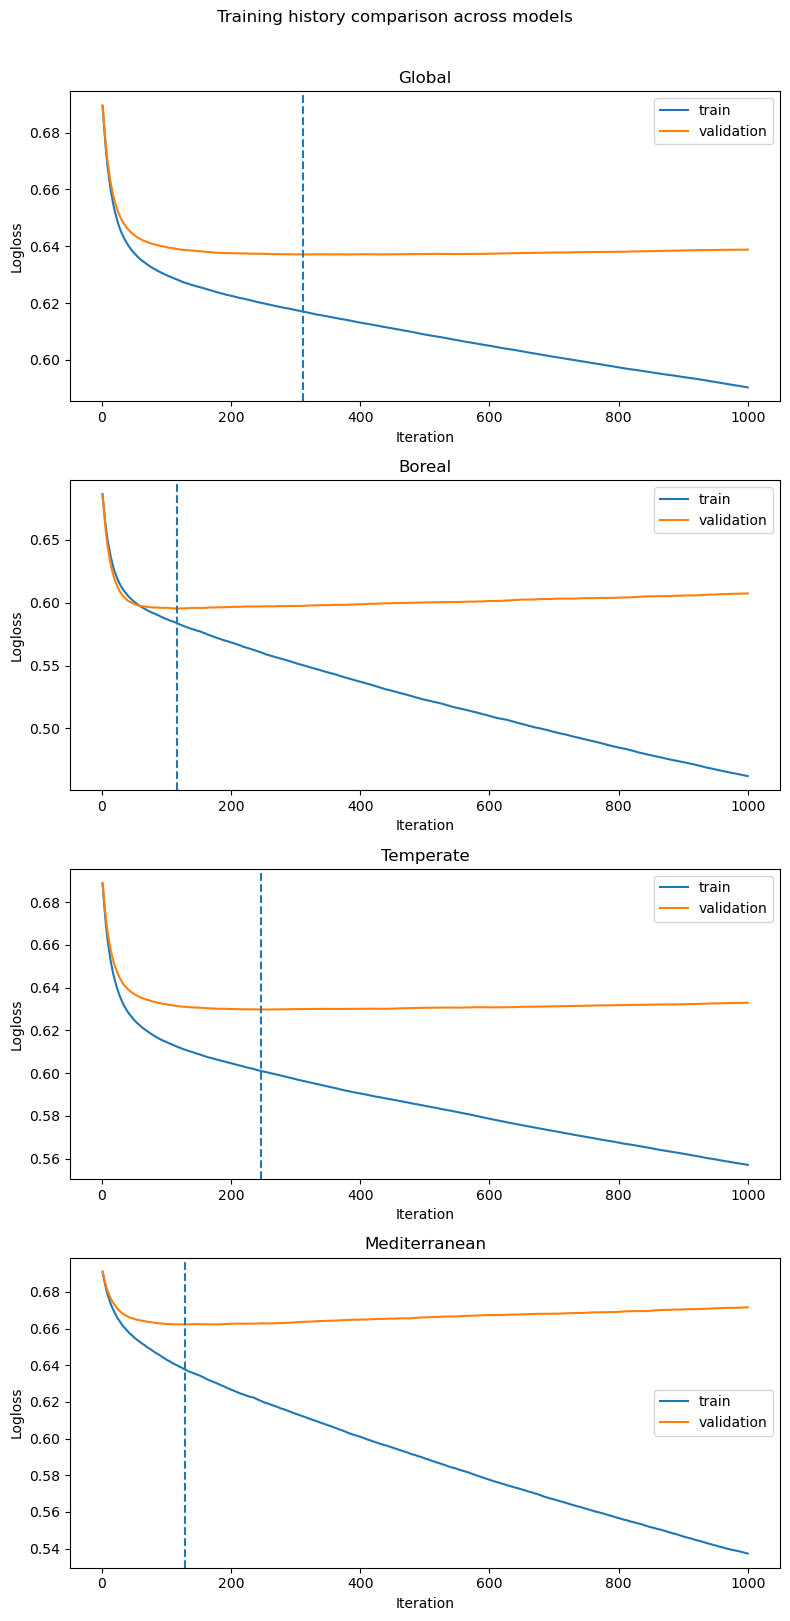

In [16]:
# 3) Training history comparison
n_models = len(results)
fig, axes = plt.subplots(n_models, 1, figsize=(8, 4 * n_models), sharex=False)

if n_models == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, results.items()):
    elog = res["evaluation_log"].copy()
    ax.plot(elog["iter"], elog["train_logloss"], label="train")
    ax.plot(elog["iter"], elog["val_logloss"], label="validation")
    ax.axvline(res["best_iteration"], linestyle="--")
    ax.set_title(model_label(model_name))
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Logloss")
    ax.legend()

fig.suptitle("Training history comparison across models", y=1.01)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_training_history_logloss.png", dpi=300, bbox_inches="tight")
plt.show()

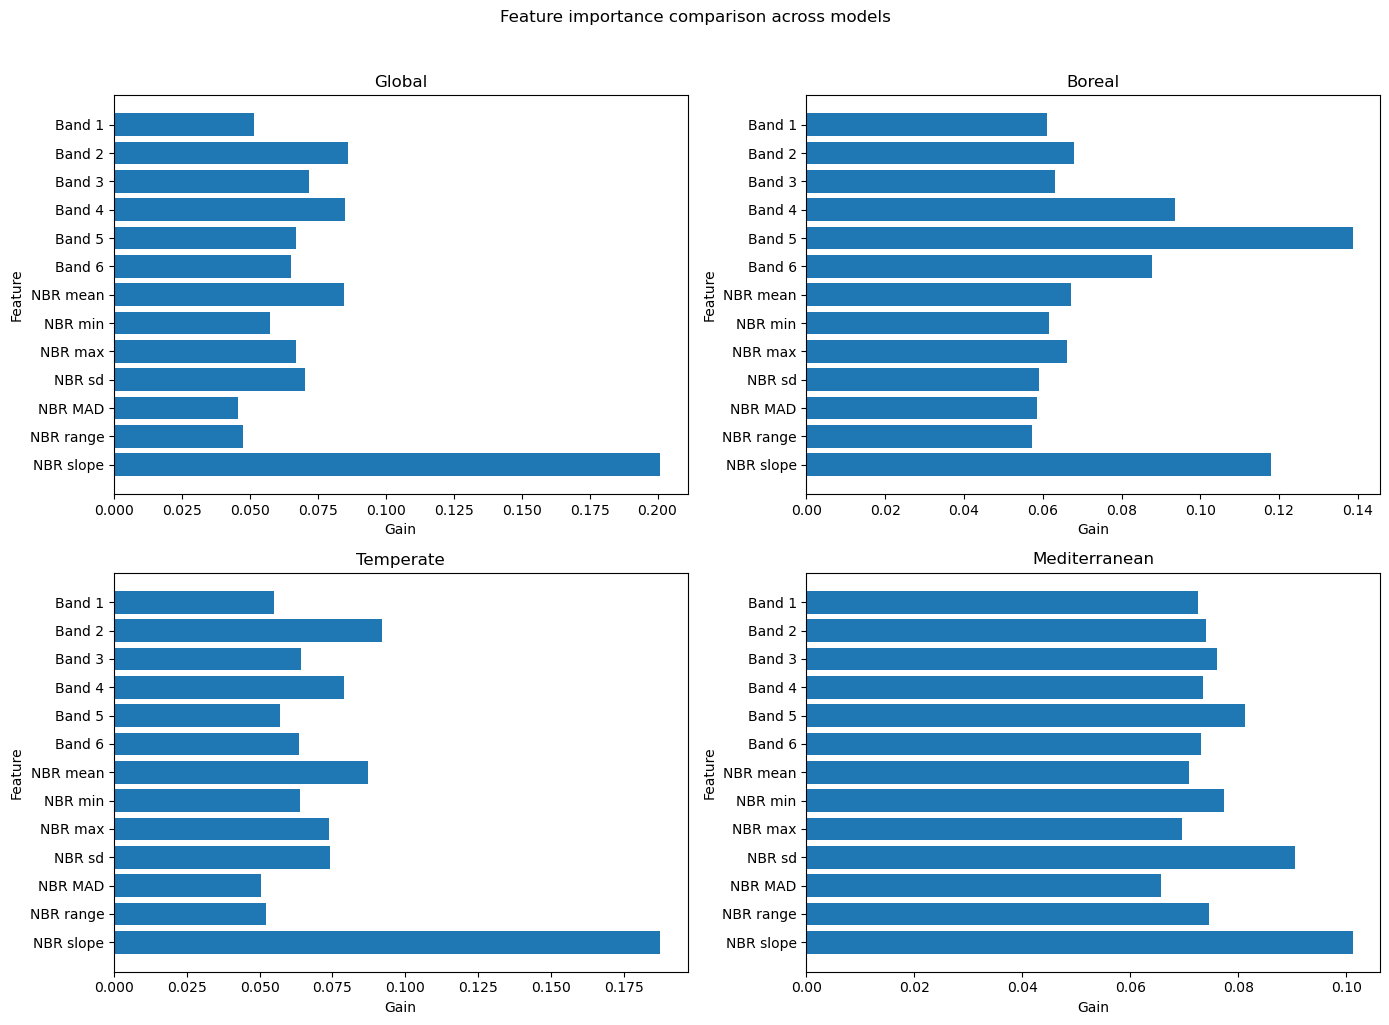

In [18]:
# 4) Feature importance comparison with requested labels and ordering
feature_order = (
    [f"Band {i}" for i in range(1, 7)]
    + ["NBR mean", "NBR min", "NBR max", "NBR sd", "NBR MAD", "NBR range", "NBR slope"]
)

imp_plot = importance_compare.copy()
imp_plot["Feature_clean"] = imp_plot["Feature"].map(feature_label)

imp_plot = imp_plot[imp_plot["Feature_clean"].isin(feature_order)].copy()

imp_plot["Feature_clean"] = pd.Categorical(
    imp_plot["Feature_clean"],
    categories=feature_order[::-1],
    ordered=True
)

imp_plot["model_clean"] = pd.Categorical(
    imp_plot["model_clean"],
    categories=model_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False, sharey=False)
axes = axes.ravel()

for ax, model_name in zip(axes, model_order):
    sub = imp_plot[imp_plot["model_clean"] == model_name].sort_values("Feature_clean")
    ax.barh(sub["Feature_clean"], sub["Gain"])
    ax.set_title(model_name)
    ax.set_xlabel("Gain")
    ax.set_ylabel("Feature")

fig.suptitle("Feature importance comparison across models", y=1.02)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_feature_importance_ordered.png", dpi=300, bbox_inches="tight")
plt.show()

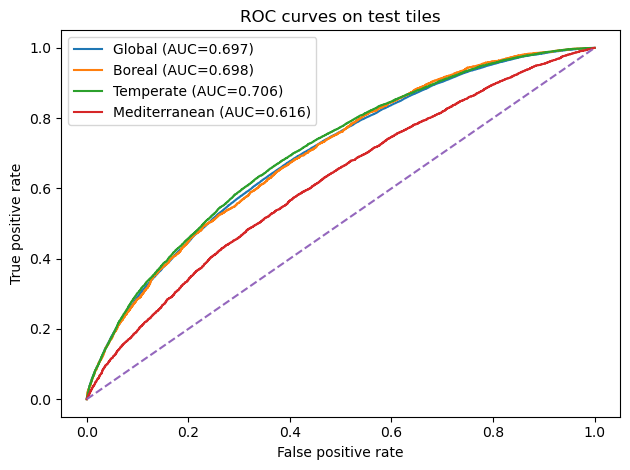

In [19]:
# 5) ROC curves on test split
fig, ax = plt.subplots()

for model_name, res in results.items():
    pred_df = res["predictions"]
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["p_undisturbed"].to_numpy()

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = safe_auc(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{model_label(model_name)} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curves on test tiles")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Short interpretation


- Test AUC / Test F1: shows whether regional models truly generalize better than the global model.   
- Training history: shows whether individual NNH models overfit more quickly or converge more stably.  
- Feature importance: shows whether the relative importance of the spectral bands and the NBR slope shifts between Boreal, Temperate, and Mediterranean.  
- ROC curves: shows differences in discrimination across all thresholds.

Model prediction

In [42]:
import sys
import subprocess

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        __import__(import_name)
        print(f"{pkg_name} already installed")
    except ImportError:
        print(f"Installing {pkg_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])

ensure_package("rasterio")
ensure_package("tqdm")
ensure_package("xgboost")
ensure_package("pandas")
ensure_package("matplotlib")

Installing rasterio ...
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 107.0 MB/s  0:00:00 eta 0:00:01
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached cligj-0.7.2-py3-none-any.whl (7.1 kB)
Using cached affine-2.4.0-py3-none-any.whl (15 kB)
Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]gins]
tqdm already installed
xgboost already installed
pandas already installed
matplotlib already installed


In [36]:
forest_mask_path = "/mnt/eo/EFDA_v211/forest_landuse_aligned.tif"
forest_values = {1}

In [75]:
def predict_from_bap_and_nbr(
    bap_median_raster,
    nbr_files_by_year,
    sen_slope_raster,
    local_forest_mask_raster,
    out_prob_raster,
    model,
    model_features,
    out_class_raster=None,
    threshold=0.5,
    nodata_values=(-10000, -9999, -32768),
    forest_values=(1,),
    block_height=512,
):
    from pathlib import Path
    import numpy as np
    import rasterio
    from rasterio.windows import Window
    from tqdm import tqdm

    nodata_values = set(nodata_values)
    forest_values = set(forest_values)
    OUT_NODATA_PROB = -9999.0
    OUT_NODATA_CLASS = 255

    with rasterio.open(bap_median_raster) as src_bap, \
         rasterio.open(sen_slope_raster) as src_slope, \
         rasterio.open(local_forest_mask_raster) as src_fmask:

        nbr_srcs = [(year, rasterio.open(fp)) for year, fp in nbr_files_by_year]

        try:
            # Sicherheitscheck: alle Tile-Produkte müssen exakt gleiches Grid haben
            for src_other, label in [(src_slope, "sen_slope"), (src_fmask, "forest_mask")]:
                same_grid = (
                    src_other.width == src_bap.width and
                    src_other.height == src_bap.height and
                    src_other.transform == src_bap.transform and
                    src_other.crs == src_bap.crs
                )
                if not same_grid:
                    raise ValueError(f"Grid mismatch between BAP and {label}")

            profile_prob = {
                "driver": "GTiff",
                "height": src_bap.height,
                "width": src_bap.width,
                "count": 1,
                "dtype": "float32",
                "crs": src_bap.crs,
                "transform": src_bap.transform,
                "nodata": OUT_NODATA_PROB,
                "compress": "ZSTD",
                "tiled": True,
                "blockxsize": 256,
                "blockysize": 256,
                "bigtiff": "IF_SAFER",
            }

            if out_class_raster is not None:
                profile_cls = {
                    "driver": "GTiff",
                    "height": src_bap.height,
                    "width": src_bap.width,
                    "count": 1,
                    "dtype": "uint8",
                    "crs": src_bap.crs,
                    "transform": src_bap.transform,
                    "nodata": OUT_NODATA_CLASS,
                    "compress": "ZSTD",
                    "tiled": True,
                    "blockxsize": 256,
                    "blockysize": 256,
                    "bigtiff": "IF_SAFER",
                }

            out_prob_raster = Path(out_prob_raster)
            if out_prob_raster.exists():
                out_prob_raster.unlink()

            if out_class_raster is not None:
                out_class_raster = Path(out_class_raster)
                if out_class_raster.exists():
                    out_class_raster.unlink()

            with rasterio.open(out_prob_raster, "w", **profile_prob) as dst_prob:
                dst_cls = rasterio.open(out_class_raster, "w", **profile_cls) if out_class_raster else None

                try:
                    for row_off in tqdm(range(0, src_bap.height, block_height),
                                        desc=f"Predicting {Path(out_prob_raster).stem}"):

                        win_h = min(block_height, src_bap.height - row_off)
                        window = Window(col_off=0, row_off=row_off, width=src_bap.width, height=win_h)

                        bap = src_bap.read(window=window).astype(np.float32)
                        if src_bap.nodata is not None:
                            bap[bap == src_bap.nodata] = np.nan
                        for nd in nodata_values:
                            bap[bap == nd] = np.nan

                        nbr_stack = []
                        for year, src in nbr_srcs:
                            arr = src.read(1, window=window).astype(np.float32)
                            if src.nodata is not None:
                                arr[arr == src.nodata] = np.nan
                            for nd in nodata_values:
                                arr[arr == nd] = np.nan
                            nbr_stack.append(arr)

                        nbr_stack = np.stack(nbr_stack, axis=0)

                        slope = src_slope.read(1, window=window).astype(np.float32)
                        if src_slope.nodata is not None:
                            slope[slope == src_slope.nodata] = np.nan
                        for nd in nodata_values:
                            slope[slope == nd] = np.nan

                        fmask = src_fmask.read(1, window=window)

                        # robuste Berechnung nur dort, wo NBR-Daten existieren
                        valid_n = np.sum(np.isfinite(nbr_stack), axis=0)

                        nbr_mean = np.full(valid_n.shape, np.nan, dtype=np.float32)
                        nbr_sd = np.full(valid_n.shape, np.nan, dtype=np.float32)
                        nbr_range = np.full(valid_n.shape, np.nan, dtype=np.float32)

                        has_data = valid_n > 0
                        if np.any(has_data):
                            nbr_mean[has_data] = np.nanmean(nbr_stack[:, has_data], axis=0).astype(np.float32)
                            nbr_sd[has_data] = np.nanstd(nbr_stack[:, has_data], axis=0).astype(np.float32)
                            nbr_min = np.nanmin(nbr_stack[:, has_data], axis=0).astype(np.float32)
                            nbr_max = np.nanmax(nbr_stack[:, has_data], axis=0).astype(np.float32)
                            nbr_range[has_data] = (nbr_max - nbr_min).astype(np.float32)

                        feature_dict = {
                            "ibap_B1_med": bap[0],
                            "ibap_B2_med": bap[1],
                            "ibap_B3_med": bap[2],
                            "ibap_B4_med": bap[3],
                            "ibap_B5_med": bap[4],
                            "ibap_B6_med": bap[5],
                            "nbr_mean": nbr_mean,
                            "nbr_sd": nbr_sd,
                            "nbr_range": nbr_range,
                            "nbr_sen_slope": slope,
                        }

                        missing = [f for f in model_features if f not in feature_dict]
                        if missing:
                            raise ValueError(f"Missing features required by model: {missing}")

                        feat_arrays = [feature_dict[f] for f in model_features]
                        X = np.stack(feat_arrays, axis=0)
                        n_features, n_rows, n_cols = X.shape
                        X = np.moveaxis(X, 0, -1).reshape(-1, n_features)

                        forest_mask_flat = np.isin(fmask.reshape(-1), list(forest_values))
                        feature_valid_flat = np.isfinite(X).all(axis=1)
                        valid_mask = forest_mask_flat & feature_valid_flat

                        prob = np.full(X.shape[0], OUT_NODATA_PROB, dtype=np.float32)
                        if valid_mask.any():
                            prob[valid_mask] = model.predict_proba(X[valid_mask])[:, 1].astype(np.float32)

                        dst_prob.write(prob.reshape(n_rows, n_cols), 1, window=window)

                        if dst_cls is not None:
                            cls = np.full(X.shape[0], OUT_NODATA_CLASS, dtype=np.uint8)
                            cls[valid_mask] = (prob[valid_mask] >= threshold).astype(np.uint8)
                            dst_cls.write(cls.reshape(n_rows, n_cols), 1, window=window)

                finally:
                    if dst_cls is not None:
                        dst_cls.close()

        finally:
            for _, src in nbr_srcs:
                src.close()

In [60]:
from pathlib import Path
import re

tile_dirs = [
    "/mnt/dss_europe/level3_interpolated/X0002_Y0026/",
    "/mnt/dss_europe/level3_interpolated/X0014_Y0019/",
    "/mnt/dss_europe/level3_interpolated/X0016_Y0007/",
]

bap_median_dir = Path("/mnt/eo/EO4Backcasting/_bap_local/2303")
sen_slope_dir  = Path("/mnt/eo/EO4Backcasting/_sen_slope_1985_1995/tile_slopes")

nbr_years = set(range(1985, 1996))  # 1985-1995 inclusive

nbr_pattern  = re.compile(r"^(\d{4})\d{4}.*NBR.*\.tif$", re.IGNORECASE)

def list_nbr_files_for_years(tile_dir, years):
    tile_dir = Path(tile_dir)
    files = []
    for f in sorted(tile_dir.iterdir()):
        if not f.is_file():
            continue
        m = nbr_pattern.match(f.name)
        if m is None:
            continue
        year = int(m.group(1))
        if year in years:
            files.append((year, f))
    return files

def find_bap_median_file(tile_name, bap_median_dir):
    fp = bap_median_dir / f"{tile_name}_IBAP_median_1985_1989.tif"
    if not fp.exists():
        raise FileNotFoundError(f"Median BAP file not found: {fp}")
    return fp

def find_sen_slope_file(tile_name, sen_slope_dir):
    candidates = sorted(sen_slope_dir.glob(f"*{tile_name}*.tif"))
    if len(candidates) == 0:
        raise FileNotFoundError(f"No sen-slope raster found for {tile_name} in {sen_slope_dir}")
    if len(candidates) > 1:
        print(f"Warning: multiple sen-slope files found for {tile_name}, using {candidates[0].name}")
    return candidates[0]

In [61]:
# from pathlib import Path

# out_dir = Path("/mnt/eo/EO4Backcasting/_bap_local/2303")

# for fp in out_dir.glob("*IBAP_median_1985_1989.tif"):
#     try:
#         fp.unlink()
#         print("Deleted:", fp)
#     except Exception as e:
#         print("Could not delete:", fp, e)

Deleted: /mnt/eo/EO4Backcasting/_bap_local/2303/X0002_Y0026_IBAP_median_1985_1989.tif
Deleted: /mnt/eo/EO4Backcasting/_bap_local/2303/X0014_Y0019_IBAP_median_1985_1989.tif
Deleted: /mnt/eo/EO4Backcasting/_bap_local/2303/X0016_Y0007_IBAP_median_1985_1989.tif


In [62]:
import re
from pathlib import Path
import numpy as np
import rasterio
from rasterio.windows import Window
from tqdm import tqdm

tile_dirs = [
    "/mnt/dss_europe/level3_interpolated/X0002_Y0026/",
    "/mnt/dss_europe/level3_interpolated/X0014_Y0019/",
    "/mnt/dss_europe/level3_interpolated/X0016_Y0007/",
]

out_dir = Path("/mnt/eo/EO4Backcasting/_bap_local/2303")
out_dir.mkdir(parents=True, exist_ok=True)

years = set(range(1985, 1990))
ibap_pattern = re.compile(r"^(\d{4})\d{4}.*IBAP.*\.tif$", re.IGNORECASE)
nodata_values = {-10000, -9999, -32768}
OUT_NODATA = -9999.0

def list_ibap_files_for_years(tile_dir, years):
    tile_dir = Path(tile_dir)
    files = []
    for f in sorted(tile_dir.iterdir()):
        if not f.is_file():
            continue
        m = ibap_pattern.match(f.name)
        if m is None:
            continue
        year = int(m.group(1))
        if year in years:
            files.append(f)
    return files

def compute_multitemporal_ibap_median(
    in_files,
    out_file,
    nodata_values=(-10000, -9999, -32768),
    block_height=512,
):
    if len(in_files) == 0:
        raise ValueError(f"No input files for {out_file}")

    nodata_values = set(nodata_values)

    with rasterio.open(in_files[0]) as src0:
        height = src0.height
        width = src0.width
        count = src0.count
        transform = src0.transform
        crs = src0.crs
        descriptions = src0.descriptions

        for fp in in_files[1:]:
            with rasterio.open(fp) as src:
                if (
                    src.height != height or
                    src.width != width or
                    src.count != count or
                    src.transform != transform or
                    src.crs != crs
                ):
                    raise ValueError(f"Grid mismatch: {fp}")

        profile = {
            "driver": "GTiff",
            "height": height,
            "width": width,
            "count": count,
            "dtype": "float32",
            "crs": crs,
            "transform": transform,
            "nodata": OUT_NODATA,
            "compress": "ZSTD",
            "tiled": True,
            "blockxsize": 256,
            "blockysize": 256,
            "bigtiff": "IF_SAFER",
        }

    out_file = Path(out_file)
    if out_file.exists():
        out_file.unlink()

    with rasterio.open(out_file, "w", **profile) as dst:
        for row_off in tqdm(range(0, height, block_height), desc=f"Writing {out_file.name}"):
            win_h = min(block_height, height - row_off)
            window = Window(col_off=0, row_off=row_off, width=width, height=win_h)

            stack_list = []
            for fp in in_files:
                with rasterio.open(fp) as src:
                    arr = src.read(window=window).astype(np.float32)

                    if src.nodata is not None:
                        arr[arr == src.nodata] = np.nan
                    for nd in nodata_values:
                        arr[arr == nd] = np.nan

                    stack_list.append(arr)

            stack = np.stack(stack_list, axis=0)   # (time, band, row, col)
            med = np.nanmedian(stack, axis=0).astype(np.float32)
            med[np.isnan(med)] = OUT_NODATA

            dst.write(med, window=window)

        try:
            dst.descriptions = descriptions
        except Exception:
            pass

In [63]:
median_outputs = []

for td in tile_dirs:
    tile_name = Path(td).name
    ibap_files = list_ibap_files_for_years(td, years)

    print(f"\n{tile_name}")
    print(f"IBAP files found for 1985-1989: {len(ibap_files)}")
    for f in ibap_files:
        print(" ", f.name)

    if len(ibap_files) == 0:
        raise FileNotFoundError(f"No IBAP files found for {tile_name} in 1985-1989")

    out_file = out_dir / f"{tile_name}_IBAP_median_1985_1989.tif"

    compute_multitemporal_ibap_median(
        in_files=ibap_files,
        out_file=out_file,
        nodata_values=nodata_values,
        block_height=512,
    )
    median_outputs.append(out_file)

print("\nCreated median rasters:")
for fp in median_outputs:
    print(fp)


X0002_Y0026
IBAP files found for 1985-1989: 5
  19850801_LEVEL3_LNDLG_IBAP.tif
  19860801_LEVEL3_LNDLG_IBAP.tif
  19870801_LEVEL3_LNDLG_IBAP.tif
  19880801_LEVEL3_LNDLG_IBAP.tif
  19890801_LEVEL3_LNDLG_IBAP.tif


Writing X0002_Y0026_IBAP_median_1985_1989.tif: 100%|█████████████████████████████████████████████████| 10/10 [00:55<00:00,  5.58s/it]



X0014_Y0019
IBAP files found for 1985-1989: 5
  19850801_LEVEL3_LNDLG_IBAP.tif
  19860801_LEVEL3_LNDLG_IBAP.tif
  19870801_LEVEL3_LNDLG_IBAP.tif
  19880801_LEVEL3_LNDLG_IBAP.tif
  19890801_LEVEL3_LNDLG_IBAP.tif


Writing X0014_Y0019_IBAP_median_1985_1989.tif: 100%|█████████████████████████████████████████████████| 10/10 [00:54<00:00,  5.42s/it]



X0016_Y0007
IBAP files found for 1985-1989: 5
  19850801_LEVEL3_LNDLG_IBAP.tif
  19860801_LEVEL3_LNDLG_IBAP.tif
  19870801_LEVEL3_LNDLG_IBAP.tif
  19880801_LEVEL3_LNDLG_IBAP.tif
  19890801_LEVEL3_LNDLG_IBAP.tif


Writing X0016_Y0007_IBAP_median_1985_1989.tif: 100%|█████████████████████████████████████████████████| 10/10 [00:55<00:00,  5.54s/it]


Created median rasters:
/mnt/eo/EO4Backcasting/_bap_local/2303/X0002_Y0026_IBAP_median_1985_1989.tif
/mnt/eo/EO4Backcasting/_bap_local/2303/X0014_Y0019_IBAP_median_1985_1989.tif
/mnt/eo/EO4Backcasting/_bap_local/2303/X0016_Y0007_IBAP_median_1985_1989.tif


In [72]:
from pathlib import Path
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

forest_mask_path = "/mnt/eo/EFDA_v211/forest_landuse_aligned.tif"
forest_values = {1}

local_fmask_dir = Path("/mnt/eo/EO4Backcasting/_bap_local/2303/local_forest_masks")
local_fmask_dir.mkdir(parents=True, exist_ok=True)

def build_local_forest_mask(tile_raster, forest_mask_mosaic, out_mask_raster, forest_nodata=255):
    tile_raster = Path(tile_raster)
    out_mask_raster = Path(out_mask_raster)

    if out_mask_raster.exists():
        out_mask_raster.unlink()

    with rasterio.open(tile_raster) as src_tile, rasterio.open(forest_mask_mosaic) as src_fmask:
        dst_arr = np.full((src_tile.height, src_tile.width), forest_nodata, dtype=np.uint8)

        reproject(
            source=rasterio.band(src_fmask, 1),
            destination=dst_arr,
            src_transform=src_fmask.transform,
            src_crs=src_fmask.crs,
            dst_transform=src_tile.transform,
            dst_crs=src_tile.crs,
            dst_nodata=forest_nodata,
            resampling=Resampling.nearest,
        )

        profile = {
            "driver": "GTiff",
            "height": src_tile.height,
            "width": src_tile.width,
            "count": 1,
            "dtype": "uint8",
            "crs": src_tile.crs,
            "transform": src_tile.transform,
            "nodata": forest_nodata,
            "compress": "ZSTD",
            "tiled": True,
            "blockxsize": 256,
            "blockysize": 256,
            "bigtiff": "IF_SAFER",
        }

        with rasterio.open(out_mask_raster, "w", **profile) as dst:
            dst.write(dst_arr, 1)

    return out_mask_raster

In [73]:
local_fmask_paths = {}

for tile_name, info in tile_inputs.items():
    out_mask = local_fmask_dir / f"{tile_name}_forestmask.tif"

    print(f"Building local forest mask for {tile_name}")
    build_local_forest_mask(
        tile_raster=info["bap_median"],
        forest_mask_mosaic=forest_mask_path,
        out_mask_raster=out_mask,
    )

    local_fmask_paths[tile_name] = out_mask
    print("  ->", out_mask)

Building local forest mask for X0002_Y0026
  -> /mnt/eo/EO4Backcasting/_bap_local/2303/local_forest_masks/X0002_Y0026_forestmask.tif
Building local forest mask for X0014_Y0019
  -> /mnt/eo/EO4Backcasting/_bap_local/2303/local_forest_masks/X0014_Y0019_forestmask.tif
Building local forest mask for X0016_Y0007
  -> /mnt/eo/EO4Backcasting/_bap_local/2303/local_forest_masks/X0016_Y0007_forestmask.tif


In [74]:
for tile_name, mask_fp in local_fmask_paths.items():
    with rasterio.open(mask_fp) as src:
        arr = src.read(1)
        vals, counts = np.unique(arr, return_counts=True)
        print("\n", tile_name)
        print("unique values:", dict(zip(vals.tolist(), counts.tolist())))
        print("nodata:", src.nodata)


 X0002_Y0026
unique values: {1: 10010995, 255: 14989005}
nodata: 255.0

 X0014_Y0019
unique values: {1: 9837837, 255: 15162163}
nodata: 255.0

 X0016_Y0007
unique values: {1: 22133827, 255: 2866173}
nodata: 255.0


In [64]:
tile_inputs = {}

for td in tile_dirs:
    tile_name = Path(td).name
    bap_fp = find_bap_median_file(tile_name, bap_median_dir)
    slope_fp = find_sen_slope_file(tile_name, sen_slope_dir)
    nbr_files = list_nbr_files_for_years(td, nbr_years)

    print(f"\n{tile_name}")
    print("  BAP median :", bap_fp.name)
    print("  Sen slope  :", slope_fp.name)
    print("  NBR files  :", len(nbr_files), "years")
    print("  Years      :", [y for y, _ in nbr_files])

    tile_inputs[tile_name] = {
        "tile_dir": Path(td),
        "bap_median": bap_fp,
        "sen_slope": slope_fp,
        "nbr_files": nbr_files,
    }


X0002_Y0026
  BAP median : X0002_Y0026_IBAP_median_1985_1989.tif
  Sen slope  : slope_NBR_1985_1995_X0002_Y0026.tif
  NBR files  : 11 years
  Years      : [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995]

X0014_Y0019
  BAP median : X0014_Y0019_IBAP_median_1985_1989.tif
  Sen slope  : slope_NBR_1985_1995_X0014_Y0019.tif
  NBR files  : 11 years
  Years      : [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995]

X0016_Y0007
  BAP median : X0016_Y0007_IBAP_median_1985_1989.tif
  Sen slope  : slope_NBR_1985_1995_X0016_Y0007.tif
  NBR files  : 11 years
  Years      : [1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995]


In [65]:
tile_inputs.keys()

dict_keys(['X0002_Y0026', 'X0014_Y0019', 'X0016_Y0007'])

In [66]:
pred_dir = Path("/mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model")
pred_dir.mkdir(parents=True, exist_ok=True)

print(pred_dir)


print("tile_inputs defined:", "tile_inputs" in globals())
print("model defined:", "model" in globals())
print("MODEL_FEATURES defined:", "MODEL_FEATURES" in globals())
print("forest_mask_path defined:", "forest_mask_path" in globals())
print("pred_dir defined:", "pred_dir" in globals())


/mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model
tile_inputs defined: True
model defined: True
MODEL_FEATURES defined: True
forest_mask_path defined: True
pred_dir defined: True


In [67]:
# load model
model_path = Path("/mnt/eo/EO4Backcasting/_training_output/2303/global/xgb_model_final.json")

print("Model exists:", model_path.exists(), model_path)

model = xgb.XGBClassifier()
model.load_model(model_path)

print("Model loaded.")

Model exists: True /mnt/eo/EO4Backcasting/_training_output/2303/global/xgb_model_final.json
Model loaded.


In [68]:
[k for k in globals().keys() if k.lower().startswith("x") or "train" in k.lower() or "feature" in k.lower()]

['xgb',
 'TRAIN_FRAC',
 'XGB_PARAMS',
 'feature_label',
 'FEATURE_COLS',
 'feature_order',
 'X_boreal',
 'nbr_features',
 'MODEL_FEATURES']

In [69]:
MODEL_FEATURES = [
    "ibap_B1_med",
    "ibap_B2_med",
    "ibap_B3_med",
    "ibap_B4_med",
    "ibap_B5_med",
    "ibap_B6_med",
    "nbr_mean",
    "nbr_sd",
    "nbr_range",
    "nbr_sen_slope",
]

In [70]:
print(MODEL_FEATURES)
print("n_features:", len(MODEL_FEATURES))

['ibap_B1_med', 'ibap_B2_med', 'ibap_B3_med', 'ibap_B4_med', 'ibap_B5_med', 'ibap_B6_med', 'nbr_mean', 'nbr_sd', 'nbr_range', 'nbr_sen_slope']
n_features: 10


In [77]:
prediction_outputs = []

for tile_name, info in tile_inputs.items():
    out_prob = pred_dir / f"{tile_name}_prob_undisturbed20y_forestonly.tif"
    out_cls  = pred_dir / f"{tile_name}_class_undisturbed20y_forestonly.tif"

    print(f"\nApplying model to {tile_name}")

    predict_from_bap_and_nbr(
        bap_median_raster=info["bap_median"],
        nbr_files_by_year=info["nbr_files"],
        sen_slope_raster=info["sen_slope"],
        local_forest_mask_raster=local_fmask_paths[tile_name],
        out_prob_raster=out_prob,
        model=model,
        model_features=MODEL_FEATURES,
        out_class_raster=out_cls,
        threshold=0.5,
        nodata_values=nodata_values,
        forest_values=forest_values,
        block_height=512,
    )

    prediction_outputs.append((tile_name, out_prob, out_cls))

print("\nCreated outputs:")
for tile_name, prob_fp, cls_fp in prediction_outputs:
    print(tile_name)
    print("  probability:", prob_fp)
    print("  class      :", cls_fp)


Applying model to X0002_Y0026


Predicting X0002_Y0026_prob_undisturbed20y_forestonly: 100%|█████████████████████████████████████████| 10/10 [00:23<00:00,  2.39s/it]



Applying model to X0014_Y0019


Predicting X0014_Y0019_prob_undisturbed20y_forestonly: 100%|█████████████████████████████████████████| 10/10 [00:24<00:00,  2.43s/it]



Applying model to X0016_Y0007


Predicting X0016_Y0007_prob_undisturbed20y_forestonly: 100%|█████████████████████████████████████████| 10/10 [00:27<00:00,  2.79s/it]



Created outputs:
X0002_Y0026
  probability: /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0002_Y0026_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0002_Y0026_class_undisturbed20y_forestonly.tif
X0014_Y0019
  probability: /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0014_Y0019_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0014_Y0019_class_undisturbed20y_forestonly.tif
X0016_Y0007
  probability: /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0016_Y0007_prob_undisturbed20y_forestonly.tif
  class      : /mnt/eo/EO4Backcasting/_bap_local/2303/predictions_global_model/X0016_Y0007_class_undisturbed20y_forestonly.tif


In [ ]:
tile_name, prob_fp, cls_fp = prediction_outputs[0]

with rasterio.open(prob_fp) as src:
    arr = src.read(1)

plt.figure(figsize=(8, 8))
plt.imshow(arr, vmin=0, vmax=1)
plt.colorbar(label="P(undisturbed_20y = 1)")
plt.title(f"{tile_name}: probability forest was undisturbed in prior 20-year window")
plt.axis("off")
plt.show()